## Notebook 2: GRIDS / MASKS 

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
SUMMARY OF NOTEBOOK
</blockquote>

In [1]:
# Repo-root discovery + import of cityheat
import sys
from pathlib import Path

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand / "cityheat").is_dir() and (cand / "configs").is_dir():
            return cand
    raise RuntimeError("Could not find repo root with 'cityheat' and 'configs' folders.")

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
C = bootstrap("Rome")  # switch to "Barcelona" later

PROJECT, CITY, CFG, cfg = C["PROJECT"], C["CITY"], C["CFG"], C["cfg"]
OUT, INT, BASE = C["OUT"], C["INT"], C["BASE"]
p_LCZ, p_UrbClim, p_GVI, p_CoolEff = C["p_LCZ"], C["p_UrbClim"], C["p_GVI"], C["p_CoolEff"]

print("Repo root:", ROOT)
print("✔ Loaded config:", CFG)
print("→ Outputs:", OUT)
print("→ Data base:", BASE)

Repo root: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat
✔ Loaded config: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/configs/rome.yml
→ Outputs: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/Rome
→ Data base: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/Rome


In [2]:
import geopandas as gpd

fua_path = BASE / "rome_fua_ghs_4326.geojson"
if not fua_path.exists():
    fua_path = BASE / "rome_fua_ghs_4326.shp"  # fallback
if not fua_path.exists():
    raise FileNotFoundError(f"FUA not found under {BASE}. Expected geojson or shp.")

fua = gpd.read_file(fua_path)
if fua.empty:
    raise ValueError("Loaded FUA is empty.")
print("FUA CRS:", fua.crs)

FUA CRS: EPSG:4326


## WBGT hot-days GeoTIFFs

In [3]:
from pathlib import Path
import rasterio as rio

from pathlib import Path

DATA_DIR = BASE  # points to PROJECT/data/Rome

years = [2030, 2050, 2070, 2090, 2100]
indicator_token = "WBGT-dayover28_0.5_absolute"

def find_tif(year: int) -> Path:
    patt = f"impact_geo_curpol_rome_urbclim-{indicator_token}_{year}_*.tif"
    matches = sorted(DATA_DIR.glob(patt))
    if not matches:
        raise FileNotFoundError(f"No GeoTIFF found for {year} with pattern: {patt}\nSearched in: {DATA_DIR}")
    if len(matches) > 1:
        print(f"[WARN] Multiple matches for {year}; using first after sort:\n  {matches}")
    return matches[0]

tif_paths = {y: find_tif(y) for y in years}

print("WBGT (hot-days) files:")
for y, p in tif_paths.items():
    print(f"  {y}: {p}")

print("\n— Raster metadata quick check —")
all_epsg = set()
for y, p in tif_paths.items():
    with rio.open(p) as src:
        crs = src.crs
        epsg = crs.to_epsg() if crs else None
        resx, resy = src.res
        print(f"{y}: {p.name}")
        print(f"    CRS: {crs}")
        print(f"    EPSG: {epsg}")
        print(f"    Resolution: {resx} x {resy}")
        print(f"    Size: {src.width} x {src.height}")
        print(f"    Bounds: {src.bounds}")
        print(f"    NoData: {src.nodata}")
        all_epsg.add(epsg)

if len(all_epsg) == 1:
    print(f"\nAll rasters share the same EPSG: {list(all_epsg)[0]}")
else:
    print(f"\nWARNING: Mixed EPSG across rasters: {sorted(all_epsg)}")

WBGT (hot-days) files:
  2030: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/Rome/impact_geo_curpol_rome_urbclim-WBGT-dayover28_0.5_absolute_2030_0.0010541181798942034.tif
  2050: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/Rome/impact_geo_curpol_rome_urbclim-WBGT-dayover28_0.5_absolute_2050_0.0010541181798942034.tif
  2070: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/Rome/impact_geo_curpol_rome_urbclim-WBGT-dayover28_0.5_absolute_2070_0.0010541181798942034.tif
  2090: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/Rome/impact_geo_curpol_rome_urbclim-WBGT-dayover28_0.5_absolute_2090_0.0010541181798942034.tif
  2100: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/Rome/impact_geo_curpol_rome_urbclim-WBGT-dayover28_0.5_absolute_2100_0.0010541181798942034.tif

— Raster metadata quick check —
2030: impact_geo_curpol_rome_urbclim-WBGT-dayover28_0.5_absolute_2030_0.0010541181798942034.tif
   

- Single reference grid: WBGT raster (2030) (to differentiate from the FUA: just a polygon mask we use to crop everything to Rome). 
- Otherwise, pixel size, CRS, affine transform, width/height... comes from one WBGT raster and we force all other rasters/vectors to line up with that grid 
- Reprojecting vectors to the raster CRS and resampling other rasters onto the reference raster's grid 

## Helpers

In [4]:
import numpy as np, geopandas as gpd
from rasterio.mask import mask as rio_mask
from rasterio.warp import reproject
from rasterio.enums import Resampling

# Here we open a raster and we project the FUA polygon to the raster's CRS so the polygon and the pixels are in the same coordinate system
# Masking and cropping the raster to the FUA's bounding window : keep data inside FUA, set outside to Nan, return the cropped array plus its transform/CRS/metadata
# Bc analysis will be Rome FUA 

def read_and_mask_to_fua(raster_path: Path, fua_gdf: gpd.GeoDataFrame):
    with rio.open(raster_path) as src:
        fua_in_raster_crs = fua_gdf.to_crs(src.crs)
        geoms = [geom for geom in fua_in_raster_crs.geometry if geom is not None]
        if not geoms:
            raise ValueError("FUA geometry is empty or invalid.")
        out, out_transform = rio_mask(
            src,
            geoms,
            crop=True,
            filled=True,
            nodata=np.nan,    # fill outside with nas directly
        )
        out_meta = src.meta.copy()
        out_meta.update({
            "height": out.shape[1],
            "width":  out.shape[2],
            "transform": out_transform
        })
        data = out[0].astype(float)  # single-band
        return data, out_transform, src.crs, out_meta
        
# Force any other raster onto the same reference grid (CRS/transform/shape),
# after masking to the FUA as well.
def ensure_on_reference_grid_bilinear(src_path: Path, ref_meta, ref_data_shape, fua_gdf: gpd.GeoDataFrame):
    """
    Return (array_on_ref, ref_meta) with the FUA mask applied; resample if needed.
    """
    src_data, src_transform, src_crs, src_meta = read_and_mask_to_fua(src_path, fua_gdf)

    same_grid = (
        (src_meta["crs"] == ref_meta["crs"]) and
        (src_meta["transform"] == ref_meta["transform"]) and
        (src_data.shape == ref_data_shape)
    )
    if same_grid:
        return src_data, ref_meta

    # resampling onto the reference grid (bilinear is fine because ratser of hot days)
    dst = np.full(ref_data_shape, np.nan, dtype=float)
    reproject(
        source=src_data,
        destination=dst,
        src_transform=src_meta["transform"],
        src_crs=src_meta["crs"],
        dst_transform=ref_meta["transform"],
        dst_crs=ref_meta["crs"],
        resampling=Resampling.bilinear,
        src_nodata=np.nan,
        dst_nodata=np.nan,
    )
    return dst, ref_meta

In [5]:
# Reference grid from 2030 WBGT hot-days, masked to FUA
# Picking one WBGT raster and masking it to the FUA
# its metadata becomes the reference grid for everything 
# why so important ? Because CLIMADA needs hazard and exposure to share exact centroid coordinates
ref_year = years[0]
ref_data, ref_transform, ref_crs, ref_meta = read_and_mask_to_fua(tif_paths[ref_year], fua)
print(f"Reference grid (year {ref_year}) shape:", ref_data.shape, "| CRS:", ref_crs)

Reference grid (year 2030) shape: (266, 353) | CRS: EPSG:4326


**Age-grouped** WorldPop data

In [6]:
# WorldPop age groups on native grid, then onto WBGT ref grid 

from rasterio.warp import reproject
from rasterio.enums import Resampling
import numpy as np
import rasterio as rio
import geopandas as gpd

year    = 2030
release = "R2025A"
version = "v1"
gender  = "t"

AGE_GROUPS = {
    "<15":   ["00", "01", "05", "10"],
    "15-64": ["15","20","25","30","35","40","45","50","55","60"],
    "65+":   ["65","70","75","80","85","90"],
}
ALL_CODES = [c for L in AGE_GROUPS.values() for c in L]

def worldpop_age_path(code):
    return BASE / f"ita_{gender}_{code}_{year}_CN_100m_{release}_{version}.tif"

def build_age_group_rasters(fua_gdf):
    agg = {"<15": None, "15-64": None, "65+": None}
    wp_meta = None
    for code in ALL_CODES:
        arr, _, _, meta = read_and_mask_to_fua(worldpop_age_path(code), fua_gdf)
        arr = np.nan_to_num(arr, nan=0.0).astype(np.float32)
        if wp_meta is None:
            wp_meta = meta
        for grp, codes in AGE_GROUPS.items():
            if code in codes:
                agg[grp] = arr if agg[grp] is None else (agg[grp] + arr)
                break
    for k, v in agg.items():
        if v is None:
            agg[k] = np.zeros_like(next(x for x in agg.values() if x is not None), dtype=np.float32)
    return agg, wp_meta

age_native, wp_meta = build_age_group_rasters(fua)

print("Native-grid totals within FUA (people):")
for k, v in age_native.items():
    print(f"  {k:>5}: {float(v.sum()):,.0f}")

def reproject_sum_to_ref(src_arr, src_meta, ref_meta, ref_like):
    out = np.zeros_like(ref_like, dtype=float)
    reproject(
        source=np.nan_to_num(src_arr, nan=0.0),
        destination=out,
        src_transform=src_meta["transform"],
        src_crs=src_meta["crs"],
        dst_transform=ref_meta["transform"],
        dst_crs=ref_meta["crs"],
        resampling=Resampling.sum,
        src_nodata=0.0,
        dst_nodata=0.0,
    )
    return np.where(np.isfinite(ref_like), out, 0.0)

# total pop then age bands on ref grid
pop_native = sum(np.nan_to_num(v, nan=0.0) for v in age_native.values())
pop_on_ref = reproject_sum_to_ref(pop_native, wp_meta, ref_meta, ref_data)

age_on_ref = {
    grp: reproject_sum_to_ref(arr, wp_meta, ref_meta, ref_data)
    for grp, arr in age_native.items()
}

native_total = float(pop_native.sum())
ref_total    = float(pop_on_ref.sum())
print("\nPopulation totals (people):")
print(f"  WP-native sum over FUA  : {native_total:,.0f}")
print(f"  WBGT-grid sum (reproj)  : {ref_total:,.0f}")

Native-grid totals within FUA (people):
    <15: 399,821
  15-64: 2,251,596
    65+: 952,085

Population totals (people):
  WP-native sum over FUA  : 3,603,501
  WBGT-grid sum (reproj)  : 2,550,386


In [7]:
assert pop_on_ref.shape == (ref_meta["height"], ref_meta["width"]), "Pop grid != ref grid shape"
for k, a in age_on_ref.items():
    assert a.shape == pop_on_ref.shape, f"Age band {k} shape != ref grid"

In [8]:
# defining mask for later
CITY_MASK = np.isfinite(ref_data) & (pop_on_ref > 0) # main analysis mask         

# Consistency check: do age bands add up to pop_on_ref?
pop_from_ages = np.zeros_like(pop_on_ref, dtype=float)
for a in age_on_ref.values():
    pop_from_ages += np.nan_to_num(a)

abs_diff = float(np.abs(np.nansum(pop_from_ages) - np.nansum(pop_on_ref)))
rel_diff = abs_diff / max(np.nansum(pop_on_ref), 1.0)

print("\nSanity check — totals on WBGT grid (people):")
for k, v in age_on_ref.items():
    print(f"  {k:>5}: {float(np.nansum(v)):.0f}")
print(f"  Sum(age bands): {float(np.nansum(pop_from_ages)):.0f}") # yes it does
print(f"  pop_on_ref    : {float(np.nansum(pop_on_ref)):.0f}")
print(f"  Abs diff      : {abs_diff:.3f}  ({100*rel_diff:.4f}%)")


Sanity check — totals on WBGT grid (people):
    <15: 277389
  15-64: 1581728
    65+: 691269
  Sum(age bands): 2550386
  pop_on_ref    : 2550386
  Abs diff      : 0.001  (0.0000%)


In [9]:
import json
with open(INT / "exposure_meta.json", "w") as f:
    json.dump({"worldpop_year": 2030}, f)

In [10]:
# some stat on WBGT hazard 
wbgt_hot_days = {}
for y in years:
    arr, _ = ensure_on_reference_grid_bilinear(tif_paths[y], ref_meta, ref_data.shape, fua)
    wbgt_hot_days[y] = arr
    v = arr[np.isfinite(arr)]
    print(f"{y}: min={np.nanmin(v):.1f}, median={np.nanmedian(v):.1f}, 95p={np.nanpercentile(v,95):.1f}, max={np.nanmax(v):.1f}")

2030: min=0.0, median=36.3, 95p=49.2, max=61.0
2050: min=0.0, median=45.2, 95p=57.0, max=67.4
2070: min=0.8, median=56.0, 95p=67.0, max=76.8
2090: min=2.0, median=66.6, 95p=76.4, max=85.0
2100: min=2.7, median=70.5, 95p=79.9, max=89.0


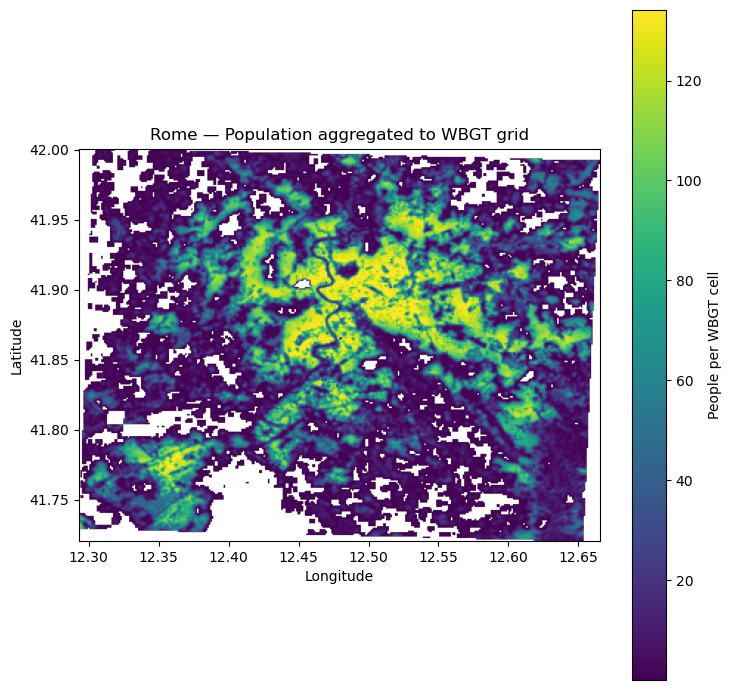

In [11]:
import matplotlib.pyplot as plt
from rasterio.transform import array_bounds

plot_arr = np.where(CITY_MASK, pop_on_ref, np.nan)
h, w = plot_arr.shape
left, bottom, right, top = array_bounds(h, w, ref_meta["transform"])
vmax = np.nanpercentile(plot_arr, 99)

plt.figure(figsize=(7.5, 7))
im = plt.imshow(plot_arr, extent=(left, right, bottom, top), origin='upper', vmax=vmax)
cb = plt.colorbar(im); cb.set_label("People per WBGT cell")
plt.title("Rome — Population aggregated to WBGT grid")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.gca().set_aspect('equal', 'box')
plt.tight_layout(); plt.show()

Saving for later

In [12]:
import json, numpy as np, rasterio as rio
from rasterio.crs import CRS

epsg = ref_meta["crs"].to_epsg()
ref_meta_slim = {
    "crs_epsg": int(epsg) if epsg is not None else None,
    "crs_wkt": ref_meta["crs"].to_wkt(),
    "transform": list(ref_meta["transform"]),
    "width": ref_meta["width"],
    "height": ref_meta["height"],
}

(OUT / "interim").mkdir(parents=True, exist_ok=True)
with open(INT / "ref_meta.json", "w") as f:
    json.dump(ref_meta_slim, f, indent=2)

tmpl_path = INT / "template_ref.tif"
profile = ref_meta.copy()
profile.update(dtype="float32", count=1, nodata=np.float32(np.nan))
with rio.open(tmpl_path, "w", **profile) as dst:
    dst.write(np.full((ref_meta["height"], ref_meta["width"]), np.nan, dtype="float32"), 1)

np.savez_compressed(INT / "city_mask.npz", city_mask=CITY_MASK.astype(np.uint8))

mask_tif = INT / "city_mask.tif"
with rio.open(mask_tif, "w", **{**profile, "dtype":"uint8", "nodata":0}) as dst:
    dst.write(CITY_MASK.astype("uint8"), 1)

In [13]:
fua_out = OUT / "rome_fua.gpkg"
fua.to_file(fua_out, layer="fua", driver="GPKG")

In [14]:
manifest = {
    "indicator_token": indicator_token,
    "years": years,
    "files": {str(y): str(tif_paths[y]) for y in years} 
}
with open(INT / "hazard_manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)
print("Saved:", INT / "ref_meta.json", INT / "template_ref.tif", INT / "city_mask.npz", INT / "hazard_manifest.json", fua_out, sep="\n  - ")

Saved:
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/Rome/interim/ref_meta.json
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/Rome/interim/template_ref.tif
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/Rome/interim/city_mask.npz
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/Rome/interim/hazard_manifest.json
  - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/Rome/rome_fua.gpkg


In [15]:
# Saving exposure rasters on ref grid 
np.savez_compressed(INT / "age_on_ref.npz",
                    lt15=age_on_ref["<15"].astype(np.float32),
                    a15_64=age_on_ref["15-64"].astype(np.float32),
                    g65=age_on_ref["65+"].astype(np.float32))
np.savez_compressed(INT / "pop_on_ref.npz", pop=pop_on_ref.astype(np.float32))

print("Saved:", INT / "age_on_ref.npz", INT / "pop_on_ref.npz")

Saved: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/Rome/interim/age_on_ref.npz /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/Rome/interim/pop_on_ref.npz


In [16]:
# writing GeoTIFFs with the same georeferencing as template_ref.tif
gt_profile = ref_meta.copy()
gt_profile.update(dtype="float32", count=1, nodata=np.float32(np.nan))

with rio.open(INT / "pop_on_ref.tif", "w", **gt_profile) as dst:
    dst.write(pop_on_ref.astype("float32"), 1)

with rio.open(INT / "age_lt15_on_ref.tif", "w", **gt_profile) as dst:
    dst.write(age_on_ref["<15"].astype("float32"), 1)

with rio.open(INT / "age_15_64_on_ref.tif", "w", **gt_profile) as dst:
    dst.write(age_on_ref["15-64"].astype("float32"), 1)

with rio.open(INT / "age_65p_on_ref.tif", "w", **gt_profile) as dst:
    dst.write(age_on_ref["65+"].astype("float32"), 1)